In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
file_name_moi = "Bejing.csv"
file_name = "hcm_aqi_full_dataset.csv"
folder_path = "dataset"
file_path_moi = os.path.join(folder_path, file_name_moi)
file_path = os.path.join(folder_path, file_name)

df = pd.read_csv(file_path)
df_moi = pd.read_csv(file_path_moi)

In [4]:
df

,time,PM10,PM2.5,CO,NO2,O3,SO2,AQI,UV,Temperature,Humidity,Rain,Wind_Speed,Wind_Dir
0,2023-01-01 00:00:00,95.0,65.0,993.0,84.4,25.0,37.5,133,0.0,23.5,65,0.0,11.3,9
1,2023-01-01 01:00:00,86.1,59.0,846.0,70.2,28.0,30.8,133,0.0,23.0,67,0.0,10.3,12
2,2023-01-01 02:00:00,83.4,57.0,821.0,65.8,26.0,28.9,132,0.0,22.5,70,0.0,7.9,360
3,2023-01-01 03:00:00,80.1,54.8,834.0,64.0,22.0,28.5,131,0.0,22.0,73,0.0,8.3,360
4,2023-01-01 04:00:00,69.4,47.5,838.0,60.1,20.0,27.2,129,0.0,21.9,72,0.0,7.9,357
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26875,2026-01-24 19:00:00,23.3,20.9,717.0,31.5,87.0,11.5,136,0.0,26.4,66,0.0,13.1,159
26876,2026-01-24 20:00:00,20.3,18.1,652.0,30.9,76.0,11.3,124,0.0,25.4,71,0.0,12.5,150
26877,2026-01-24 21:00:00,18.0,16.0,593.0,27.8,71.0,10.7,105,0.0,24.4,78,0.0,10.4,144
26878,2026-01-24 22:00:00,16.8,15.0,547.0,25.6,67.0,10.2,82,0.0,24.1,81,0.0,8.5,144


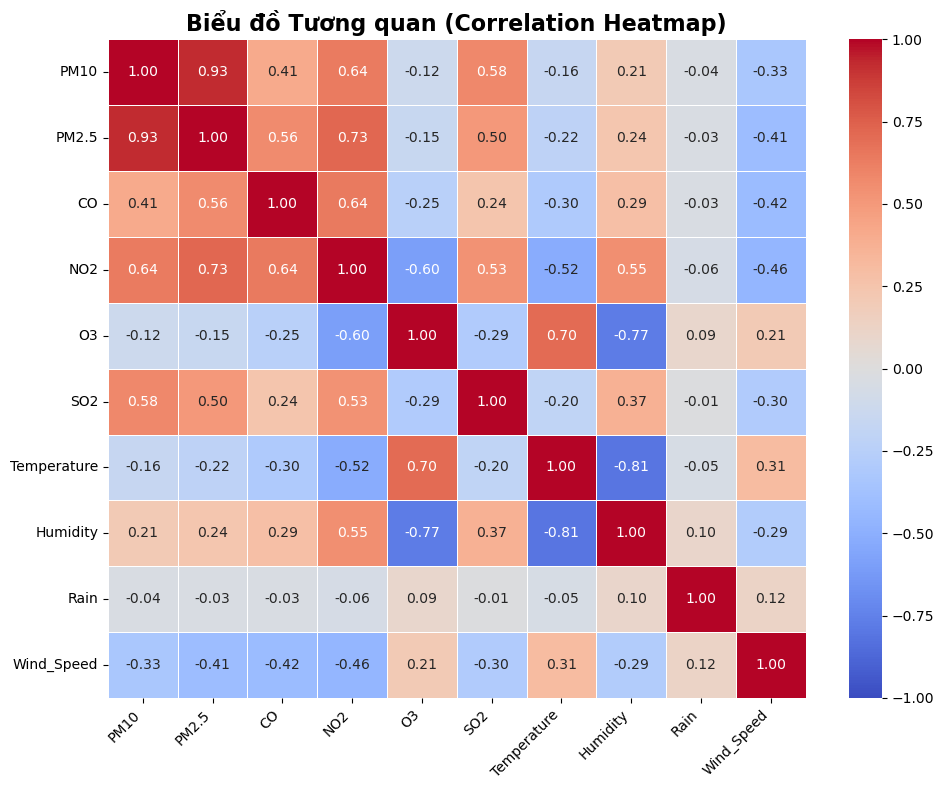

C:\Users\nguye\AppData\Local\Temp\ipykernel_11816\1022845592.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_pm25.values, y=corr_with_pm25.index, palette='coolwarm')


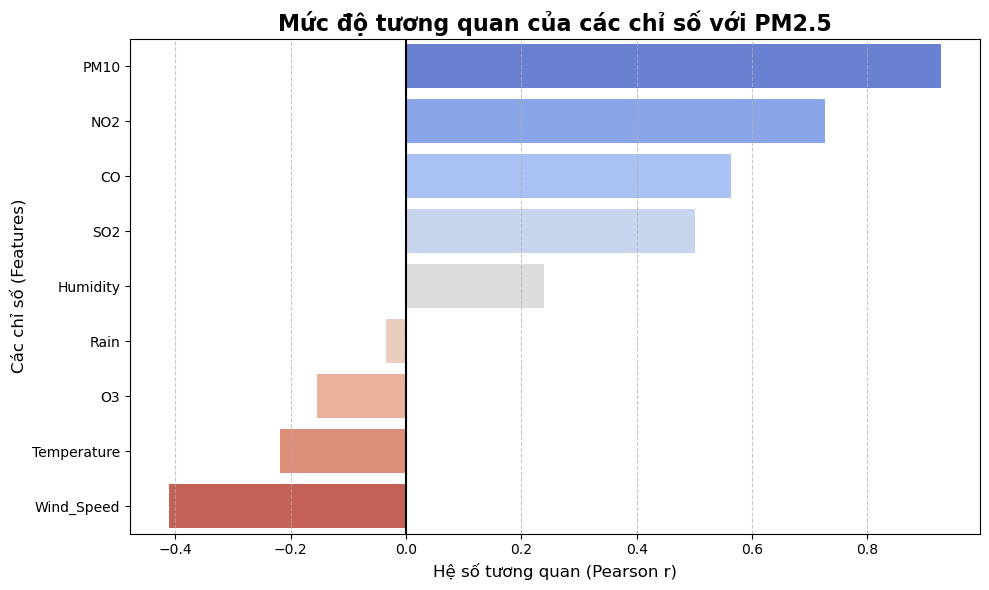

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Chỉ chọn các cột có dữ liệu dạng số (Numerical Features)
# Lưu ý: Loại bỏ Wind_Dir (hướng gió) vì nó là dữ liệu dạng vòng tròn (circular data) 
cols_to_corr = ['PM10', 'PM2.5', 'CO', 'NO2', 'O3', 'SO2', 'Temperature', 'Humidity', 'Rain', 'Wind_Speed']
existing_cols = [c for c in cols_to_corr if c in df.columns]

# Tính Ma trận tương quan (Hệ số Pearson r)
corr_matrix = df[existing_cols].corr()

# ==========================================
# BIỂU ĐỒ 1: HEATMAP TỔNG THỂ
# ==========================================
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=.5)
plt.title('Biểu đồ Tương quan (Correlation Heatmap)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ==========================================
# BIỂU ĐỒ 2: ĐỘ TƯƠNG QUAN VỚI PM2.5
# ==========================================
# Tách riêng cột PM2.5, loại bỏ chính nó (vì PM2.5 với PM2.5 luôn = 1.0) và sắp xếp giảm dần
corr_with_pm25 = corr_matrix['PM2.5'].drop('PM2.5').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_pm25.values, y=corr_with_pm25.index, palette='coolwarm')
plt.title('Mức độ tương quan của các chỉ số với PM2.5', fontsize=16, fontweight='bold')
plt.xlabel('Hệ số tương quan (Pearson r)', fontsize=12)
plt.ylabel('Các chỉ số (Features)', fontsize=12)

# Kẻ một đường line ở gốc 0 để phân biệt Tương quan thuận (Dương) và nghịch (Âm)
plt.axvline(x=0, color='black', linewidth=1.5)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler

# --- ĐỌC DỮ LIỆU ---
folder_path = "dataset"
file_path = os.path.join(folder_path, "hcm_aqi_full_dataset.csv")
file_path_moi = os.path.join(folder_path, "Bejing.csv")

df = pd.read_csv(file_path, parse_dates=['time'])
df = df.sort_values('time').set_index('time')

df_moi = pd.read_csv(file_path_moi)

# --- LÀM SẠCH KAGGLE DATASET (BẮC KINH) ---
# Thường file Bắc Kinh có cột year, month, day, hour. Ta gộp lại thành index datetime
if 'year' in df_moi.columns:
    df_moi['time'] = pd.to_datetime(df_moi[['year', 'month', 'day', 'hour']])
    df_moi = df_moi.set_index('time')
    df_moi = df_moi.drop(columns=['No', 'year', 'month', 'day', 'hour'], errors='ignore')

# Xử lý cột chữ (Categorical) thành số (One-hot encoding cho hướng gió)
if 'cbwd' in df_moi.columns:
    df_moi = pd.get_dummies(df_moi, columns=['cbwd'], drop_first=True)

# Xóa các dòng bị NaN (thường xuất hiện ở 24h đầu tiên của dataset Bắc Kinh)
df_moi = df_moi.dropna()

print(f"Kích thước HCM gốc: {df.shape}")
print(f"Kích thước Bắc Kinh đã clean: {df_moi.shape}")

Kích thước HCM gốc: (26880, 13)
Kích thước Bắc Kinh đã clean: (41757, 10)


In [13]:
def preprocess_xgboost(data, target_col, lag_steps=24, out_steps=3, test_size=0.2):
    """Biến đổi dữ liệu thành dạng bảng cho XGBoost với Lag Features."""
    df_temp = data.copy()
    
    # 1. Tạo Lag Features (Quá khứ)
    for col in df_temp.columns:
        for i in range(1, lag_steps + 1):
            df_temp[f'{col}_lag_{i}'] = df_temp[col].shift(i)
            
    # 2. Tạo Target Variables (Tương lai)
    for i in range(1, out_steps + 1):
        df_temp[f'TARGET_t+{i}'] = df_temp[target_col].shift(-i)
        
    df_temp = df_temp.dropna()
    
    # 3. Tách X, y
    y_cols = [f'TARGET_t+{i}' for i in range(1, out_steps + 1)]
    y = df_temp[y_cols].values
    X_cols = [col for col in df_temp.columns if 'lag_' in col]
    X = df_temp[X_cols].values
    
    # 4. Chia Train/Test (Time-series split)
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    return X_train, X_test, y_train, y_test

# --- ÁP DỤNG CHO 2 DATASET ---
# Lưu ý: Cột đích của HCM là 'PM2.5', của Bắc Kinh thường là 'pm2.5' (chữ thường)
hcm_target = 'PM2.5'
bj_target = 'pm2.5' if 'pm2.5' in df_moi.columns else 'PM2.5'

X_train_xgb_hcm, X_test_xgb_hcm, y_train_xgb_hcm, y_test_xgb_hcm = preprocess_xgboost(df, hcm_target)
X_train_xgb_bj, X_test_xgb_bj, y_train_xgb_bj, y_test_xgb_bj = preprocess_xgboost(df_moi, bj_target)

print("\n--- XGBoost Shape ---")
print(f"HCM XGBoost X_train: {X_train_xgb_hcm.shape}")
print(f"Bắc Kinh XGBoost X_train: {X_train_xgb_bj.shape}")

C:\Users\nguye\AppData\Local\Temp\ipykernel_65524\3707694325.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_temp[f'{col}_lag_{i}'] = df_temp[col].shift(i)
C:\Users\nguye\AppData\Local\Temp\ipykernel_65524\3707694325.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_temp[f'{col}_lag_{i}'] = df_temp[col].shift(i)
C:\Users\nguye\AppData\Local\Temp\ipykernel_65524\3707694325.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performa


--- XGBoost Shape ---
HCM XGBoost X_train: (21482, 312)
Bắc Kinh XGBoost X_train: (33384, 240)


In [14]:
def preprocess_lstm(data, target_col, time_steps=24, out_steps=3, test_size=0.2):
    """Chuẩn hóa và cắt Sliding Window thành Tensor 3D cho LSTM."""
    # 1. Chuẩn hóa dữ liệu toàn cục
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)
    
    # Lấy index của cột đích để trích xuất y
    target_idx = data.columns.get_loc(target_col)
    
    # Chuẩn hóa riêng Target để dùng cho việc dịch ngược (Inverse Transform) lúc đánh giá
    target_scaler = StandardScaler()
    target_scaler.fit(data[[target_col]])
    
    # 2. Tạo Sliding Window
    X, y = [], []
    for i in range(len(scaled_data) - time_steps - out_steps + 1):
        X.append(scaled_data[i : (i + time_steps)])
        y.append(scaled_data[(i + time_steps) : (i + time_steps + out_steps), target_idx])
        
    X, y = np.array(X), np.array(y)
    
    # 3. Chia Train/Test
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    return X_train, X_test, y_train, y_test, target_scaler

# --- ÁP DỤNG CHO 2 DATASET ---
X_train_lstm_hcm, X_test_lstm_hcm, y_train_lstm_hcm, y_test_lstm_hcm, scaler_hcm = preprocess_lstm(df, hcm_target)
X_train_lstm_bj, X_test_lstm_bj, y_train_lstm_bj, y_test_lstm_bj, scaler_bj = preprocess_lstm(df_moi, bj_target)

print("\n--- LSTM Shape ---")
print(f"HCM LSTM X_train: {X_train_lstm_hcm.shape}")
print(f"Bắc Kinh LSTM X_train: {X_train_lstm_bj.shape}")


--- LSTM Shape ---
HCM LSTM X_train: (21483, 24, 13)
Bắc Kinh LSTM X_train: (33384, 24, 10)


In [15]:
import time
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def run_xgboost_baseline(X_train, X_test, y_train, y_test, dataset_name):
    print(f"\n🚀 BẮT ĐẦU CHẠY BASELINE XGBOOST - {dataset_name.upper()}")
    
    # Khởi tạo mô hình mặc định
    model = MultiOutputRegressor(XGBRegressor(random_state=42, n_jobs=-1))
    
    # Huấn luyện
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    print(f"⏱️ Thời gian huấn luyện: {train_time:.2f} giây")
    
    # Dự báo
    start_infer = time.time()
    y_pred = model.predict(X_test)
    infer_time = time.time() - start_infer
    print(f"⚡ Thời gian suy luận: {infer_time:.4f} giây")
    
    # Đánh giá
    r2_raw = r2_score(y_test, y_pred, multioutput='raw_values')
    mae_raw = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
    rmse_raw = mean_squared_error(y_test, y_pred, multioutput='raw_values') ** 0.5
    
    print(f"\n📊 BẢNG ĐIỂM BASELINE XGBOOST ({dataset_name}):")
    print(f"{'Tầm nhìn':<10} | {'R2 Score':<10} | {'MAE':<10} | {'RMSE'}")
    print("-" * 50)
    for i in range(len(r2_raw)): 
        print(f"t + {i+1:<5} | {r2_raw[i]:.4f}     | {mae_raw[i]:.4f}     | {rmse_raw[i]:.4f}")

# --- CHẠY THỰC TẾ ---
run_xgboost_baseline(X_train_xgb_hcm, X_test_xgb_hcm, y_train_xgb_hcm, y_test_xgb_hcm, "Dữ liệu TP.HCM")
run_xgboost_baseline(X_train_xgb_bj, X_test_xgb_bj, y_train_xgb_bj, y_test_xgb_bj, "Dữ liệu Bắc Kinh (Kaggle)")


🚀 BẮT ĐẦU CHẠY BASELINE XGBOOST - DỮ LIỆU TP.HCM
⏱️ Thời gian huấn luyện: 12.54 giây
⚡ Thời gian suy luận: 0.0451 giây

📊 BẢNG ĐIỂM BASELINE XGBOOST (Dữ liệu TP.HCM):
Tầm nhìn   | R2 Score   | MAE        | RMSE
--------------------------------------------------
t + 1     | 0.8262     | 4.5031     | 6.5278
t + 2     | 0.7266     | 5.8421     | 8.1787
t + 3     | 0.6197     | 6.9585     | 9.6326

🚀 BẮT ĐẦU CHẠY BASELINE XGBOOST - DỮ LIỆU BẮC KINH (KAGGLE)
⏱️ Thời gian huấn luyện: 3.63 giây
⚡ Thời gian suy luận: 0.2086 giây

📊 BẢNG ĐIỂM BASELINE XGBOOST (Dữ liệu Bắc Kinh (Kaggle)):
Tầm nhìn   | R2 Score   | MAE        | RMSE
--------------------------------------------------
t + 1     | 0.8787     | 19.1357     | 32.8454
t + 2     | 0.8033     | 24.6602     | 41.8208
t + 3     | 0.7579     | 29.1402     | 46.4052


In [ ]:
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def run_lstm_baseline(X_train, X_test, y_train, y_test, target_scaler, dataset_name):
    print(f"\n🚀 BẮT ĐẦU CHẠY BASELINE LSTM - {dataset_name.upper()}")
    
    # Lấy thông số shape
    time_steps = X_train.shape[1]
    num_features = X_train.shape[2]
    out_steps = y_train.shape[1]
    
    # Khởi tạo mạng nơ-ron cơ bản (Baseline)
    model = Sequential([
        LSTM(units=32, return_sequences=False, input_shape=(time_steps, num_features)),
        Dense(out_steps, activation='linear')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    
    # Huấn luyện (Chạy 10 epochs cho nhanh với Baseline)
    start_time = time.time()
    model.fit(X_train, y_train, epochs=10, batch_size=64, verbose=0, validation_split=0.1)
    train_time = time.time() - start_time
    print(f"⏱️ Thời gian huấn luyện (10 Epochs): {train_time:.2f} giây")
    
    # Dự báo
    start_infer = time.time()
    y_pred_scaled = model.predict(X_test, verbose=0)
    infer_time = time.time() - start_infer
    print(f"⚡ Thời gian suy luận: {infer_time:.4f} giây")
    
    print(f"\n📊 BẢNG ĐIỂM BASELINE LSTM ({dataset_name}):")
    print(f"{'Tầm nhìn':<10} | {'R2 Score':<10} | {'MAE':<10} | {'RMSE'}")
    print("-" * 50)
    
    for i in range(out_steps):
        y_test_real = target_scaler.inverse_transform(y_test[:, i].reshape(-1, 1)).flatten()
        y_pred_real = target_scaler.inverse_transform(y_pred_scaled[:, i].reshape(-1, 1)).flatten()
        
        r2 = r2_score(y_test_real, y_pred_real)
        mae = mean_absolute_error(y_test_real, y_pred_real)
        rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
        
        print(f"t + {i+1:<5} | {r2:.4f}     | {mae:.4f}     | {rmse:.4f}")

# --- CHẠY THỰC TẾ ---
run_lstm_baseline(X_train_lstm_hcm, X_test_lstm_hcm, y_train_lstm_hcm, y_test_lstm_hcm, scaler_hcm, "Dữ liệu TP.HCM")
run_lstm_baseline(X_train_lstm_bj, X_test_lstm_bj, y_train_lstm_bj, y_test_lstm_bj, scaler_bj, "Dữ liệu Bắc Kinh (Kaggle)")


🚀 BẮT ĐẦU CHẠY BASELINE LSTM - DỮ LIỆU TP.HCM


c:\Users\nguye\miniconda3\envs\DAP\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


⏱️ Thời gian huấn luyện (10 Epochs): 34.34 giây
⚡ Thời gian suy luận: 0.6699 giây

📊 BẢNG ĐIỂM BASELINE LSTM (Dữ liệu TP.HCM):
Tầm nhìn   | R2 Score   | MAE        | RMSE
--------------------------------------------------
t + 1     | 0.8982     | 3.3937     | 4.9948
t + 2     | 0.7596     | 5.4528     | 7.6695
t + 3     | 0.6016     | 6.9933     | 9.8590

🚀 BẮT ĐẦU CHẠY BASELINE LSTM - DỮ LIỆU BẮC KINH (KAGGLE)


c:\Users\nguye\miniconda3\envs\DAP\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


⏱️ Thời gian huấn luyện (10 Epochs): 32.38 giây
⚡ Thời gian suy luận: 0.8421 giây

📊 BẢNG ĐIỂM BASELINE LSTM (Dữ liệu Bắc Kinh (Kaggle)):
Tầm nhìn   | R2 Score   | MAE        | RMSE
--------------------------------------------------
t + 1     | 0.9494     | 12.0975     | 21.2131
t + 2     | 0.8907     | 18.6636     | 31.1711
t + 3     | 0.8288     | 24.1637     | 39.0200


In [17]:
df_moi.head()

,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir,cbwd_NW,cbwd_SE,cbwd_cv
time,,,,,,,,,,
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,1.79,0,0,False,True,False
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,2.68,0,0,False,True,False
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,3.57,0,0,False,True,False
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,5.36,1,0,False,True,False
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,6.25,2,0,False,True,False


In [18]:
df

,PM10,PM2.5,CO,NO2,O3,SO2,AQI,UV,Temperature,Humidity,Rain,Wind_Speed,Wind_Dir
time,,,,,,,,,,,,,
2023-01-01 00:00:00,95.0,65.0,993.0,84.4,25.0,37.5,133,0.0,23.5,65,0.0,11.3,9
2023-01-01 01:00:00,86.1,59.0,846.0,70.2,28.0,30.8,133,0.0,23.0,67,0.0,10.3,12
2023-01-01 02:00:00,83.4,57.0,821.0,65.8,26.0,28.9,132,0.0,22.5,70,0.0,7.9,360
2023-01-01 03:00:00,80.1,54.8,834.0,64.0,22.0,28.5,131,0.0,22.0,73,0.0,8.3,360
2023-01-01 04:00:00,69.4,47.5,838.0,60.1,20.0,27.2,129,0.0,21.9,72,0.0,7.9,357
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-24 19:00:00,23.3,20.9,717.0,31.5,87.0,11.5,136,0.0,26.4,66,0.0,13.1,159
2026-01-24 20:00:00,20.3,18.1,652.0,30.9,76.0,11.3,124,0.0,25.4,71,0.0,12.5,150
2026-01-24 21:00:00,18.0,16.0,593.0,27.8,71.0,10.7,105,0.0,24.4,78,0.0,10.4,144


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử ta lấy tầm nhìn t+1 (cột số 0) để vẽ biểu đồ
# y_test_real: mảng giá trị thực tế
# y_pred_xgb_real: mảng dự báo của XGBoost
# y_pred_lstm_real: mảng dự báo của LSTM

plt.figure(figsize=(15, 6))
# Chỉ vẽ 100 mẫu đầu tiên cho dễ nhìn, vẽ nhiều quá sẽ bị rối mắt
m = 100 
plt.plot(y_test_real[:m], label='Thực tế (Actual)', color='black', linewidth=2, marker='o', markersize=4)
plt.plot(y_pred_xgb_real[:m], label='Dự báo XGBoost', color='blue', linestyle='--', linewidth=1.5)
plt.plot(y_pred_lstm_real[:m], label='Dự báo LSTM', color='red', linestyle='-.', linewidth=1.5)

plt.title('So sánh Giá trị Thực tế và Dự báo PM2.5 (Tầm nhìn t+1 trong 100 giờ đầu)', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian (Giờ)', fontsize=12)
plt.ylabel('Nồng độ PM2.5', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

NameError: name 'y_test_real' is not defined

<Figure size 1500x600 with 0 Axes>

NameError: name 'rmse_xgb' is not defined

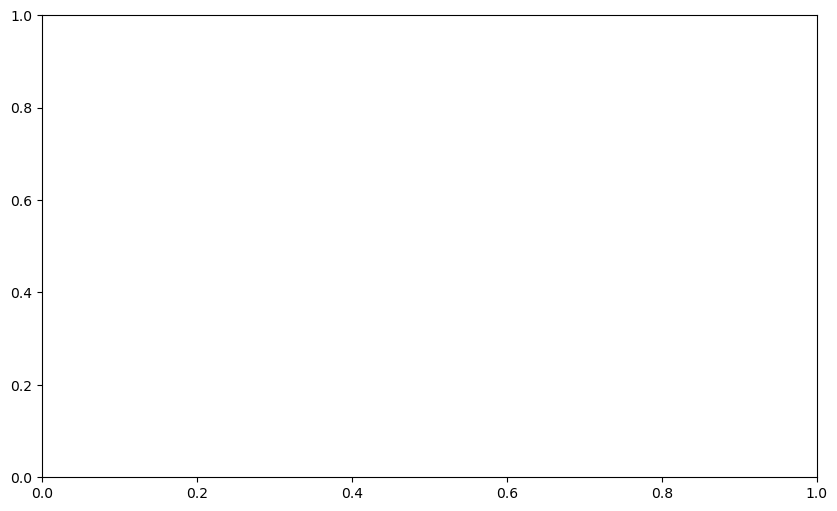

In [ ]:
import numpy as np

# Số liệu giả định (Bạn thay bằng số RMSE thực tế nhóm chạy ra nhé)
# Ví dụ: rmse_xgb = [15.2, 18.5, 22.1], rmse_lstm = [14.8, 19.0, 24.5]
labels = ['t+1', 't+2', 't+3']
x = np.arange(len(labels))  # Vị trí các nhãn
width = 0.35  # Độ rộng của cột

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, rmse_xgb, width, label='XGBoozolor='#1f77b4')
rects2 = ax.bar(x + width/2, rmse_lstm, width, label='LSTM', color='#ff7f0e')

ax.set_ylabel('Sai số RMSE (Càng thấp càng tốt)', fontsize=12)
ax.set_title('So sánh sai số RMSE giữa XGBoost và LSTM theo tầm nhìn', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.legend(fontsize=12)

# Thêm con số trên đỉnh mỗi cột cho rõ ràng
ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')

plt.tight_layout()
plt.show()